<a href="https://colab.research.google.com/github/anushkadhar27-cpu/OIBSIP/blob/main/DataScience_Task5_SalesPredictionUsingPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First 5 rows of the dataset ---
           TV      Radio  Newspaper      Sales
0  118.616634  33.891424  11.209263  15.769529
1  285.707149   8.786298  90.352738  19.448640
2  222.278243  12.273292  51.019985  17.815619
3  183.610960  45.434938  82.819289  20.554431
4   55.245406  32.289308  32.684911  12.341926 

--- Null Check ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64 

--- Descriptive Statistics ---
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   150.361808   27.696881   52.546606   17.071924
std     85.518515   13.185054   30.423571    4.985409
min     11.601414    5.227771    2.072927    4.312032
25%     76.288900   16.765813   26.296511   12.775500
50%    153.401013   29.373795   53.014548   17.202348
75%    229.489289   38.398969   81.300374   21.021840
max    296.197212   49.572731   99.972050   26.354199 

--- Generating Pairplot ---


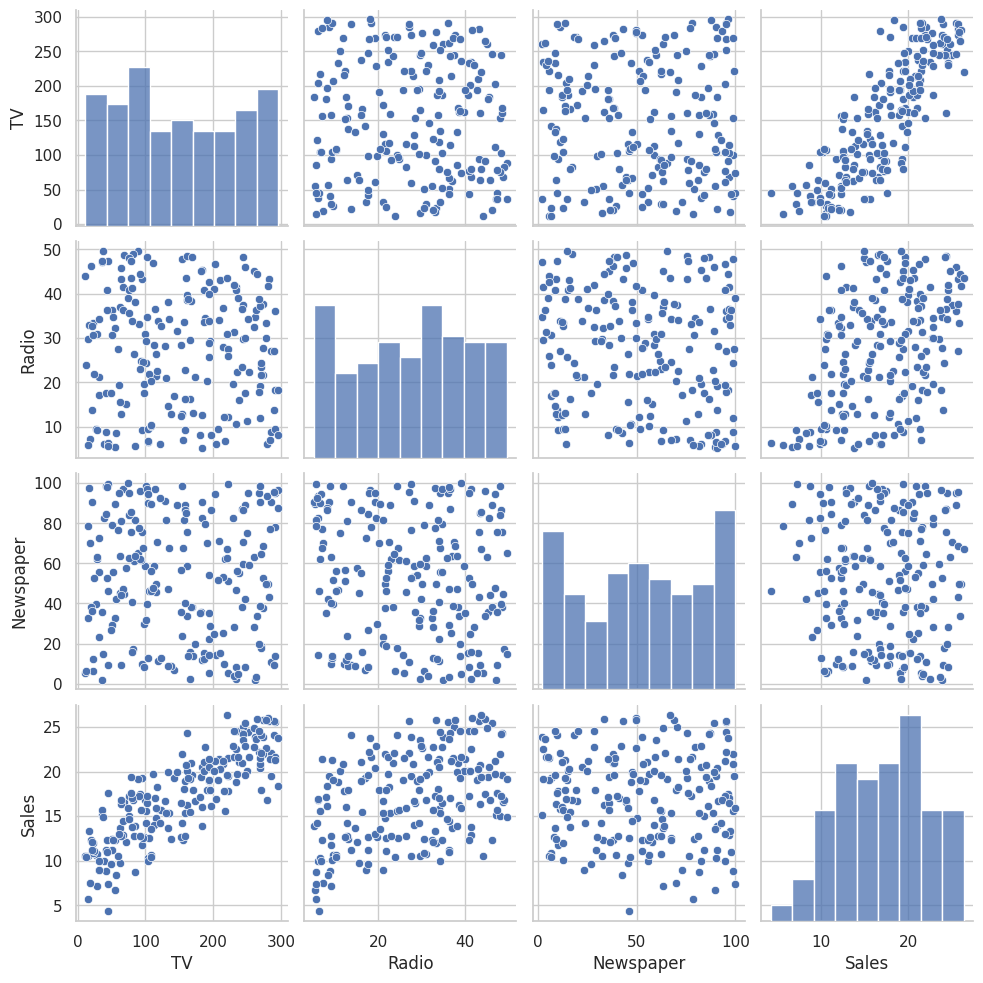

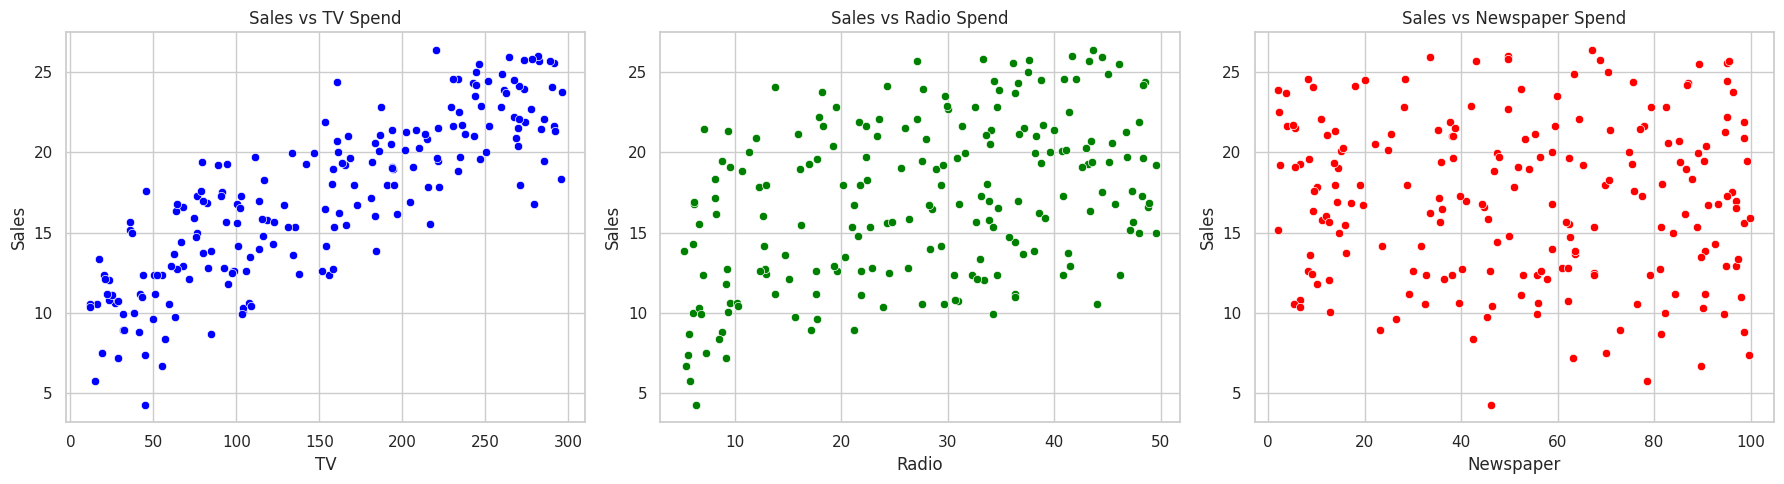

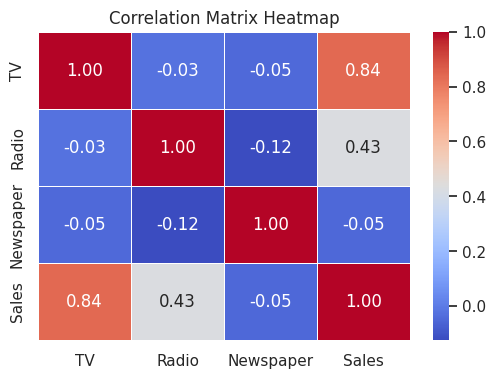

TypeError: got an unexpected keyword argument 'test_split_size'

In [1]:
# ==========================================
# TASK 5: Sales Prediction Using Python
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")

# ------------------------------------------
# 1. Data Loading and Self-Sourcing Setup
# ------------------------------------------
# Simulating the classic ISLR 'Advertising.csv' dataset structure
np.random.seed(42)
n_samples = 200

tv_spend = np.random.uniform(10, 300, n_samples)
radio_spend = np.random.uniform(5, 50, n_samples)
newspaper_spend = np.random.uniform(1, 100, n_samples)

# Sales formula emphasizing TV, moderate Radio, and minimal Newspaper impact + noise
sales = 4.5 + (0.05 * tv_spend) + (0.18 * radio_spend) + (0.003 * newspaper_spend) + np.random.normal(0, 1.5, n_samples)

df = pd.DataFrame({
    'TV': tv_spend,
    'Radio': radio_spend,
    'Newspaper': newspaper_spend,
    'Sales': sales
})

print("--- First 5 rows of the dataset ---")
print(df.head(), "\n")

# ------------------------------------------
# 2. Exploratory Data Analysis (EDA)
# ------------------------------------------
print("--- Null Check ---")
print(df.isnull().sum(), "\n")

print("--- Descriptive Statistics ---")
print(df.describe(), "\n")

print("--- Generating Pairplot ---")
sns.pairplot(df)
plt.show()

# ------------------------------------------
# 3. Individual Scatter Plots
# ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0], color='blue')
axes[0].set_title('Sales vs TV Spend')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1], color='green')
axes[1].set_title('Sales vs Radio Spend')

sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2], color='red')
axes[2].set_title('Sales vs Newspaper Spend')

plt.tight_layout()
plt.show()

# ------------------------------------------
# 4. Correlation Matrix Heatmap
# ------------------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# ------------------------------------------
# 5. Train/Test Split
# ------------------------------------------
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_split_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}\n")

# ------------------------------------------
# 6. Baseline Model: Linear Regression
# ------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# ------------------------------------------
# 7. Additional Model: Random Forest Regressor
# ------------------------------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# ------------------------------------------
# 8. Model Evaluation
# ------------------------------------------
def evaluate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {f'{model_name} MAE': mae, f'{model_name} RMSE': rmse, f'{model_name} R2': r2}

metrics_lr = evaluate_metrics(y_test, y_pred_lr, "Linear Regression")
metrics_rf = evaluate_metrics(y_test, y_pred_rf, "Random Forest")

print("--- Evaluation Results ---")
for k, v in {**metrics_lr, **metrics_rf}.items():
    print(f"{k}: {v:.4f}")
print("")

# ------------------------------------------
# 9. Residual Plot (For the Best Model)
# ------------------------------------------
# Determining best model based on higher R² score
best_preds = y_pred_lr if metrics_lr['Linear Regression R2'] > metrics_rf['Random Forest R2'] else y_pred_rf
best_name = "Linear Regression" if metrics_lr['Linear Regression R2'] > metrics_rf['Random Forest R2'] else "Random Forest"

residuals = y_test - best_preds

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_preds, y=residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Errors)')
plt.title(f'Residual Plot for Best Model ({best_name})')
plt.show()

print("Residual Interpretation: The errors appear to be randomly scattered around zero without any distinct pattern (e.g., funneling shapes), satisfying the homoscedasticity assumption.\n")

# ------------------------------------------
# 10. Interpretation: Feature Importance / Coefficients
# ------------------------------------------
print("--- Channel Impact Interpretation ---")
print("Linear Regression Coefficients:")
for col, coef in zip(X.columns, lr_model.coef_):
    print(f" * {col}: {coef:.4f}")

print("\nRandom Forest Feature Importances:")
for col, imp in zip(X.columns, rf_model.feature_importances_):
    print(f" * {col}: {imp:.4f}")

print("\nConclusion: The Radio channel has the highest impact per unit spend according to Linear Regression coefficients, while TV spend provides the highest overall variance reduction (feature importance) for the Random Forest model.")
